### Imports 

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp

### Paths

In [2]:
BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC\spatial_2"

RAW_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC\adata_all_genes.h5ad"

CLUSTERED_PATH = os.path.join(
    BASE_PATH,
    "adata_with_clusters.h5ad"
)

### Load Data

In [3]:
# RAW NORMALISED (UNSCALED) DATA
# Used ONLY for differential expression
adata_raw = sc.read_h5ad(RAW_PATH)

# SCALED + EMBEDDINGS + CLUSTERS
# Used for embeddings / UMAP / multimodal analysis
adata_clustered = sc.read_h5ad(CLUSTERED_PATH)

print("RAW:")
print(adata_raw)

print("\nCLUSTERED:")
print(adata_clustered)

RAW:
AnnData object with n_obs × n_vars = 63072 × 500
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'

CLUSTERED:
AnnData object with n_obs × n_vars = 63072 × 150
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', '

### Create Analysis Object:
##### We keep RAW EXPRESSION MATRIX but transfer embeddings + clustering

In [4]:
adata = adata_raw.copy()

CLUSTER_KEY = "leiden_Multimodal"

### Transfer Clusters

In [5]:
cluster_cols = [
    "leiden",
    "leiden_Multimodal"
]

for col in cluster_cols:
    if col in adata_clustered.obs.columns:
        adata.obs[col] = adata_clustered.obs[col].values

print(adata.obs.columns)

Index(['fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y',
       'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score',
       'predicted_doublet', 'leiden', 'leiden_Multimodal'],
      dtype='object')


### Transfer Embeddings

In [6]:
embedding_keys = [
    "X_cnn",
    "X_gene",
    "X_multi",
    "X_umap"
]

for key in embedding_keys:
    if key in adata_clustered.obsm:
        adata.obsm[key] = adata_clustered.obsm[key]

print(adata)

AnnData object with n_obs × n_vars = 63072 × 500
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_Multimodal'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_cnn', 'X_gene', 'X_multi', 'X_umap'


### Differential Expression
##### Uses RAW NORMALISED EXPRESSION NOT SCALED DATA

In [7]:
sc.tl.rank_genes_groups(
    adata,
    groupby=CLUSTER_KEY,
    method="wilcoxon",
    pts=True
)

### Marker Gene Visualization

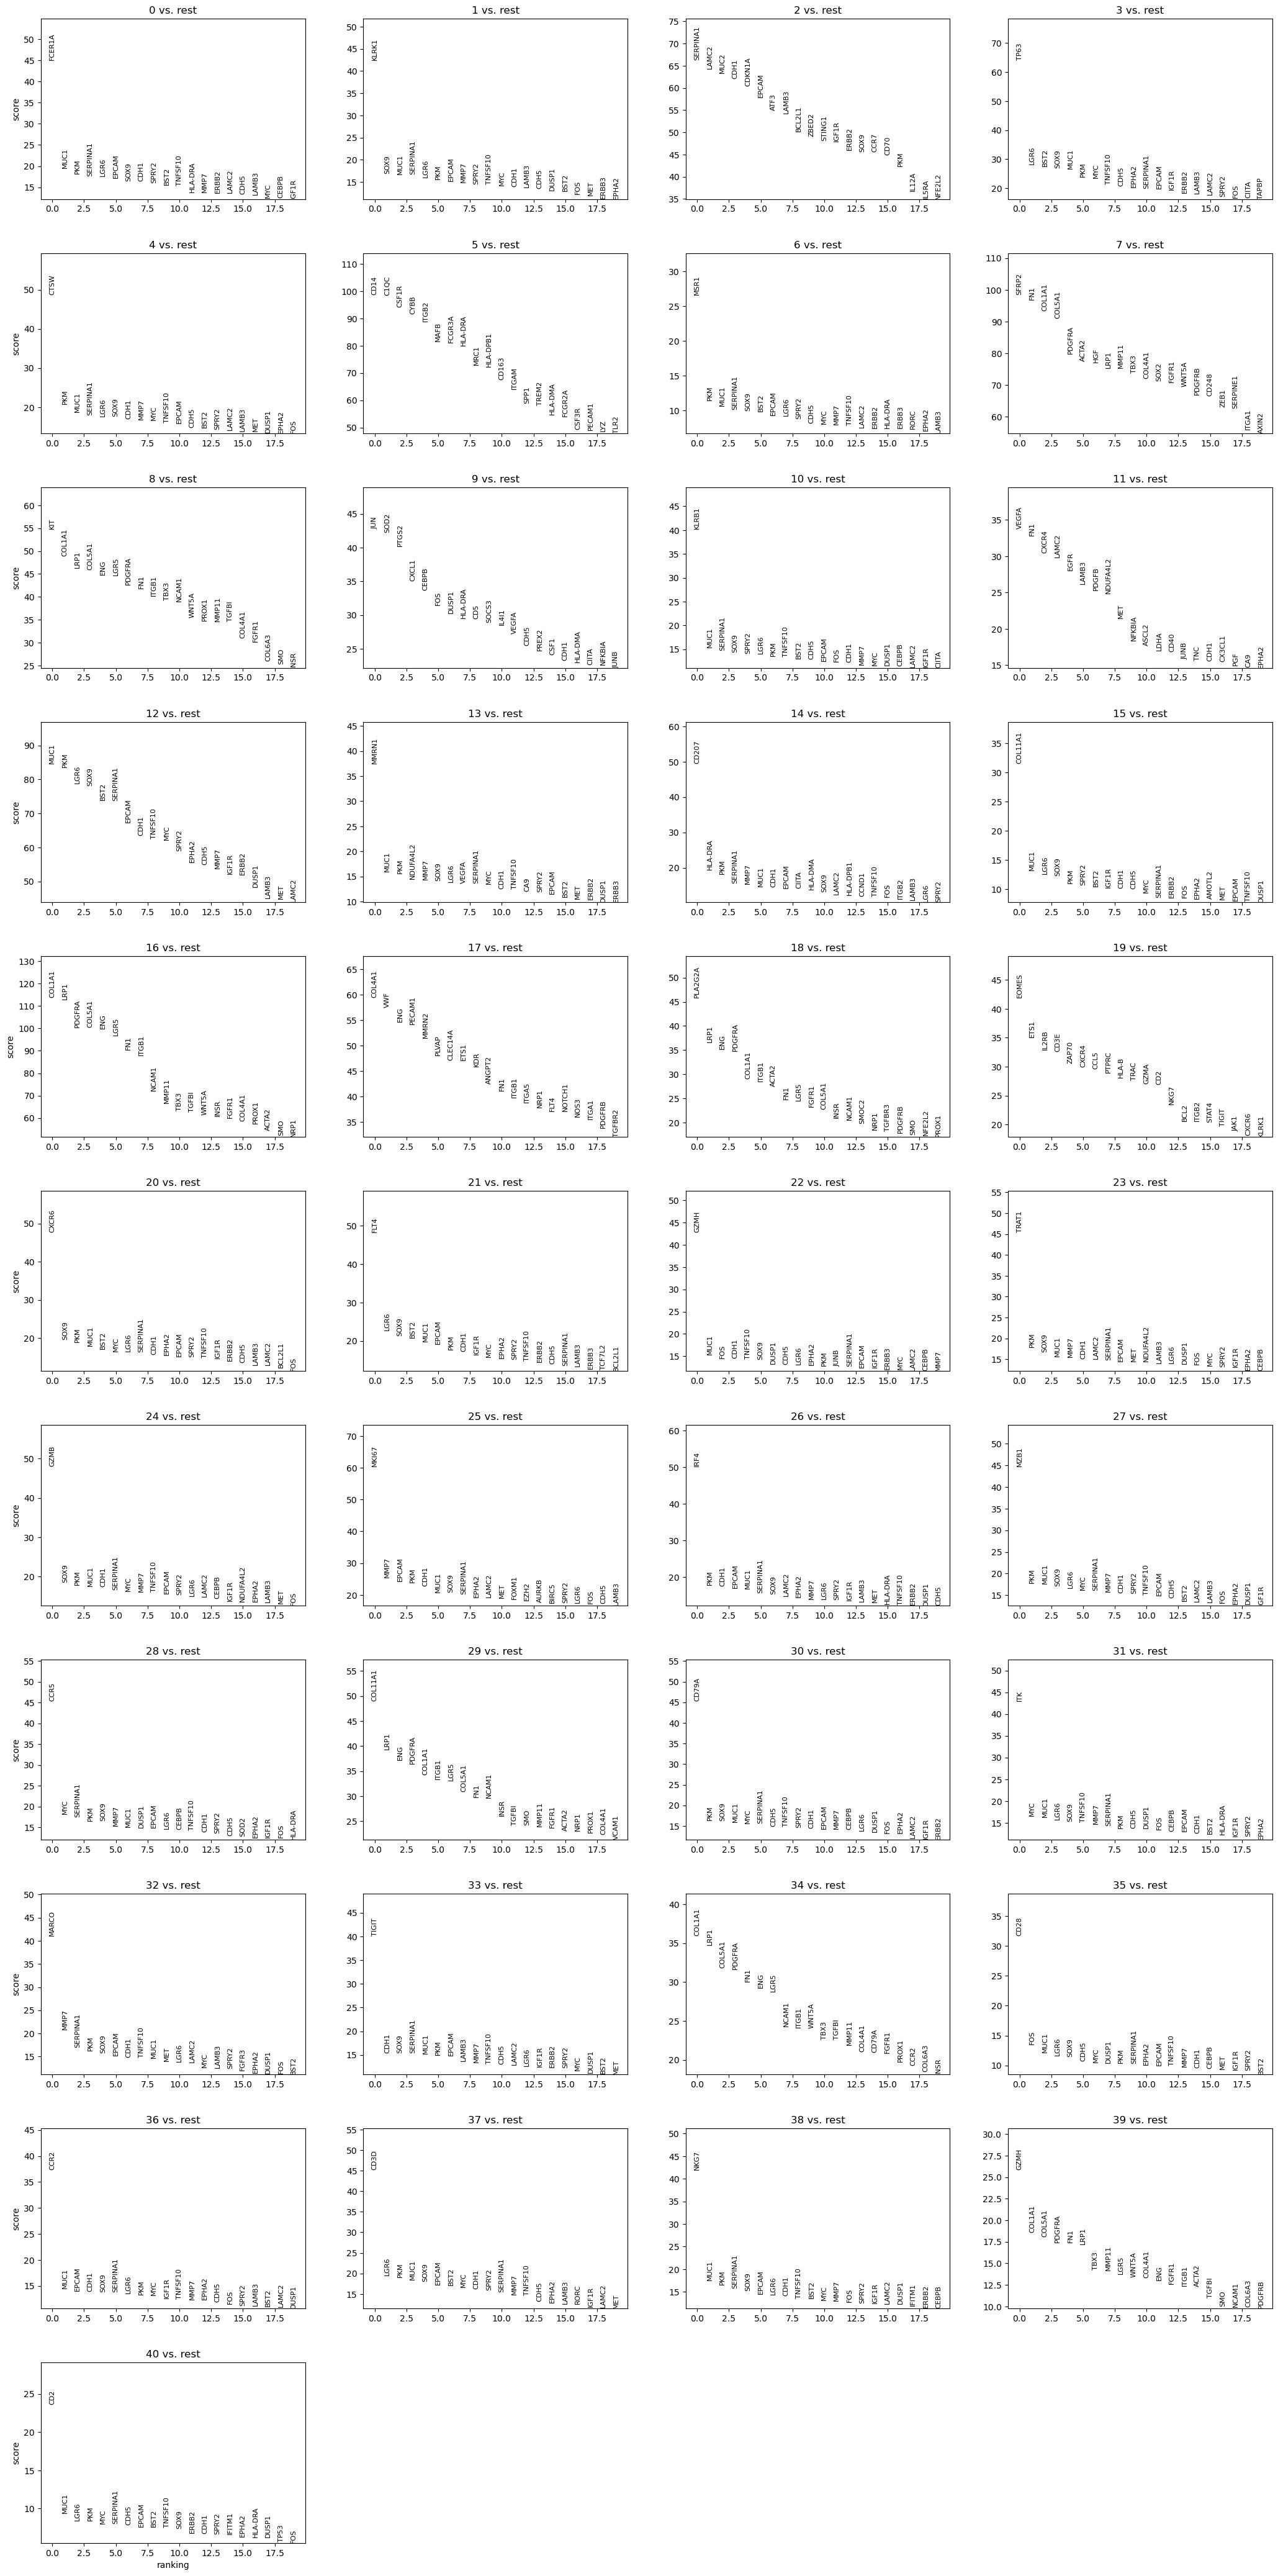

In [8]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)

### Marker Gene Visualization

In [9]:
def get_filtered_genes(adata, cluster, top_n=50):

    df = sc.get.rank_genes_groups_df(
        adata,
        group=cluster
    )

    df = df[
        (df["pvals_adj"] < 0.05) &
        (df["logfoldchanges"] > 0.25)
    ]

    df = df.sort_values(
        "logfoldchanges",
        ascending=False
    )

    # fallback
    if df.shape[0] < 10:

        df = sc.get.rank_genes_groups_df(
            adata,
            group=cluster
        )

        df = df.sort_values(
            "logfoldchanges",
            ascending=False
        )

    return df.head(top_n)

### Functional Enrichment

In [10]:
background_genes = adata.var_names.tolist()

def run_enrichment(gene_list):

    if len(gene_list) < 5:
        return None, None

    try:

        go = gp.enrichr(
            gene_list=gene_list,
            gene_sets=["GO_Biological_Process_2021"],
            organism="human",
            background=background_genes,
            outdir=None
        )

        kegg = gp.enrichr(
            gene_list=gene_list,
            gene_sets=["KEGG_2021_Human"],
            organism="human",
            background=background_genes,
            outdir=None
        )

        return go.results, kegg.results

    except Exception as e:

        print("Enrichment failed:", e)

        return None, None

### Run Enrichment Per Cluster

In [11]:
clusters = sorted(
    adata.obs[CLUSTER_KEY].unique().tolist()
)

results_summary = {}

for cl in clusters:

    print(f"Processing cluster {cl}")

    df_genes = get_filtered_genes(
        adata,
        cl
    )

    gene_list = df_genes["names"].tolist()

    go_res, kegg_res = run_enrichment(gene_list)

    results_summary[cl] = {
        "genes": df_genes,
        "GO": go_res,
        "KEGG": kegg_res
    }

Processing cluster 0
Processing cluster 1
Processing cluster 10
Processing cluster 11
Processing cluster 12
Processing cluster 13
Processing cluster 14
Processing cluster 15
Processing cluster 16
Processing cluster 17
Processing cluster 18
Processing cluster 19
Processing cluster 2
Processing cluster 20
Processing cluster 21
Processing cluster 22
Processing cluster 23
Processing cluster 24
Processing cluster 25
Processing cluster 26
Processing cluster 27
Processing cluster 28
Processing cluster 29
Processing cluster 3
Processing cluster 30
Processing cluster 31
Processing cluster 32
Processing cluster 33
Processing cluster 34
Processing cluster 35
Processing cluster 36
Processing cluster 37
Processing cluster 38
Processing cluster 39
Processing cluster 4
Processing cluster 40
Processing cluster 5
Processing cluster 6
Processing cluster 7
Processing cluster 8
Processing cluster 9


### Biological Interpretation Rules

In [12]:
def interpret_cluster(genes, pathways):

    g = " ".join(genes).lower()
    p = " ".join(pathways).lower()

    # =========================
    # Tumor / Epithelial
    # =========================

    if (
        "epcam" in g or
        "cdh1" in g or
        "muc1" in g or
        "sox9" in g or
        "lgr6" in g or
        "mmp7" in g
    ):

        if (
            "mki67" in g or
            "cell cycle" in p or
            "mitotic" in p or
            "proliferation" in p
        ):

            return "Proliferating Tumor"

        elif (
            "hypoxia" in p or
            "hif" in p or
            "ndufa4l2" in g or
            "vegfa" in g
        ):

            return "Hypoxic Tumor"

        else:

            return "Epithelial Tumor"

    # =========================
    # Fibroblast / CAF
    # =========================

    if (
        "col1a1" in g or
        "fn1" in g or
        "pdgfra" in g or
        "col5a1" in g or
        "col11a1" in g or
        "sfrp2" in g
    ):

        return "Fibroblast (CAF)"

    # =========================
    # Endothelial
    # =========================

    if (
        "pecam1" in g or
        "vwf" in g or
        "eng" in g or
        "col4a1" in g or
        "flt4" in g or
        "mmrn1" in g
    ):

        return "Endothelial"

    # =========================
    # T / NK Cells
    # =========================

    if (
        "cd3" in g or
        "gzmb" in g or
        "gzmh" in g or
        "nkg7" in g or
        "klrk1" in g or
        "eomes" in g or
        "itk" in g or
        "tigit" in g or
        "il2rb" in g
    ):

        return "T/NK Cells"

    # =========================
    # Myeloid Cells
    # =========================

    if (
        "cd14" in g or
        "csf1r" in g or
        "c1qc" in g or
        "marco" in g or
        "msr1" in g or
        "cybb" in g or
        "fcer1a" in g
    ):

        return "Myeloid Cells"

    # =========================
    # B / Plasma Cells
    # =========================

    if (
        "cd79a" in g or
        "mzb1" in g or
        "irf4" in g
    ):

        return "B / Plasma Cells"

    # =========================
    # Dendritic / APC
    # =========================

    if (
        "cd207" in g or
        "hla-dra" in g
    ):

        return "Dendritic / APC"

    # =========================
    # Inflamed TME
    # =========================

    if (
        "interferon" in p or
        "inflammatory" in p or
        "immune response" in p
    ):

        return "Inflamed TME"

    return "Mixed State"

In [13]:
# def interpret_cluster(genes, pathways):

#     g = " ".join(genes).lower()
#     p = " ".join(pathways).lower()

#     if "epcam" in g or "cdh1" in g:

#         if "mki67" in g or "cell cycle" in p:
#             return "Proliferating Tumor"

#         elif "hypoxia" in p:
#             return "Hypoxic Tumor"

#         else:
#             return "Epithelial Tumor"

#     if "col1a1" in g or "fn1" in g:
#         return "Fibroblast (CAF)"

#     if "pecam1" in g or "vwf" in g:
#         return "Endothelial"

#     if "cd3" in g or "gzmb" in g:
#         return "T/NK Cells"

#     if "cd14" in g or "csf1r" in g:
#         return "Myeloid Cells"

#     if "interferon" in p:
#         return "Inflamed TME"

#     return "Mixed State"

### Cluster Annotation Summary

In [14]:
summary = []

for cl, res in results_summary.items():

    genes = res["genes"]["names"].head(10).tolist()

    if res["GO"] is not None:
        pathways = res["GO"]["Term"].head(3).tolist()
    else:
        pathways = []

    label = interpret_cluster(
        genes,
        pathways
    )

    summary.append({
        "Cluster": cl,
        "Cell Type": label
    })

summary_df = pd.DataFrame(summary)

summary_df

,Cluster,Cell Type
0,0,Epithelial Tumor
1,1,Proliferating Tumor
2,10,Epithelial Tumor
3,11,Fibroblast (CAF)
4,12,Epithelial Tumor
5,13,Hypoxic Tumor
6,14,Epithelial Tumor
7,15,Epithelial Tumor
8,16,Fibroblast (CAF)
9,17,Endothelial


### Add Cell Type Annotations

In [15]:
cluster_map = dict(
    zip(
        summary_df["Cluster"],
        summary_df["Cell Type"]
    )
)

adata.obs["cell_type"] = (
    adata.obs[CLUSTER_KEY]
    .map(cluster_map)
)

adata.obs["cell_type"] = (
    adata.obs["cell_type"]
    .astype("category")
)

adata.obs["cell_type"].value_counts()

cell_type
Epithelial Tumor       33747
Fibroblast (CAF)       17861
Myeloid Cells           4380
Hypoxic Tumor           2051
Proliferating Tumor     1947
T/NK Cells              1583
Endothelial             1503
Name: count, dtype: int64

### UMAP Plot

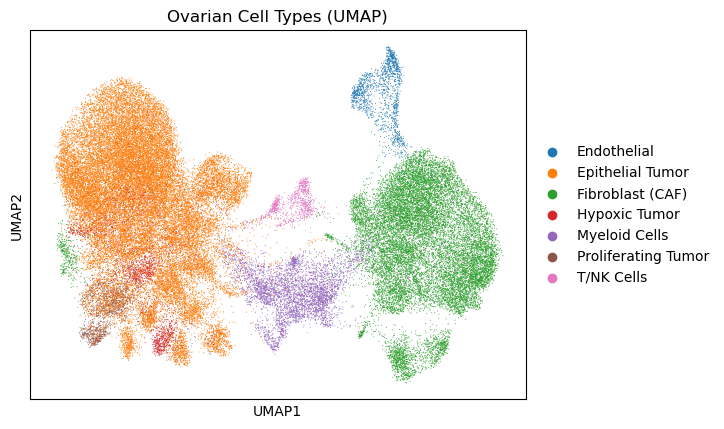

In [16]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="right margin",
    title="Ovarian Cell Types (UMAP)",
    show=False
)

plt.savefig(
    os.path.join(BASE_PATH, "celltypes_umap.pdf"),
    bbox_inches="tight"
)

plt.show()
plt.close()

### Spatial Plot

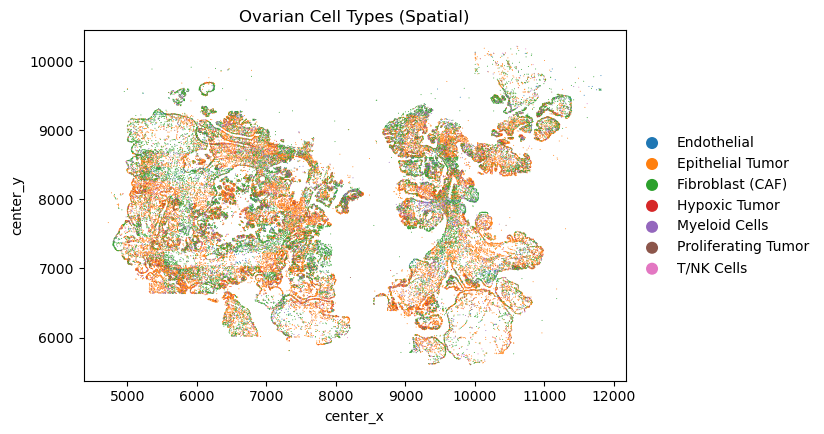

In [17]:
sc.pl.scatter(
    adata,
    x="center_x",
    y="center_y",
    color="cell_type",
    legend_loc="right margin",
    title="Ovarian Cell Types (Spatial)",
    show=False
)

plt.savefig(
    os.path.join(BASE_PATH, "celltypes_spatial.pdf"),
    bbox_inches="tight"
)

plt.show()
plt.close()

### Modality-Specific UMAPs

Running Gene


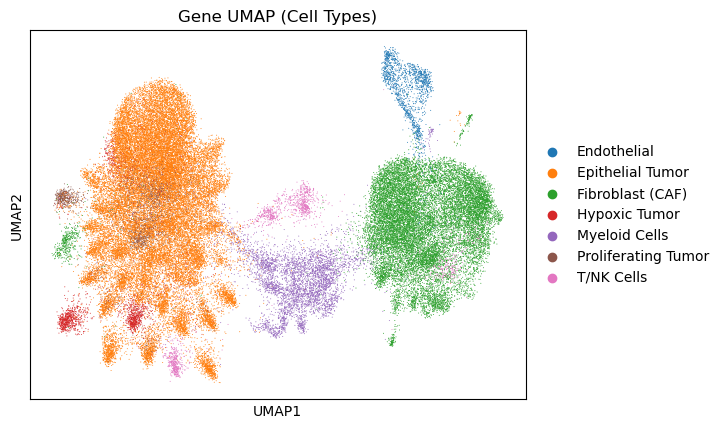

Running CNN


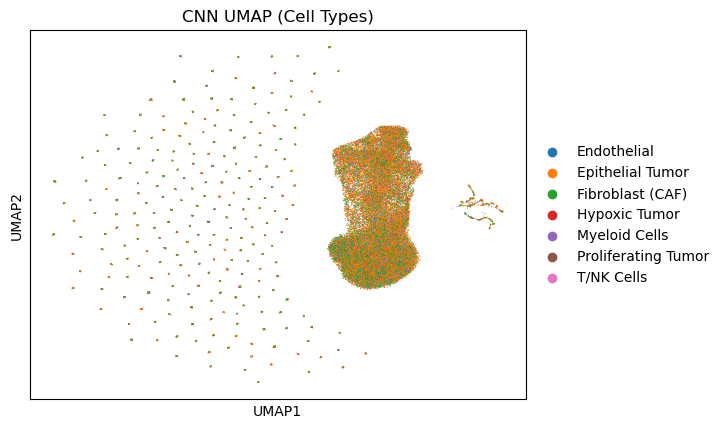

Running Multimodal


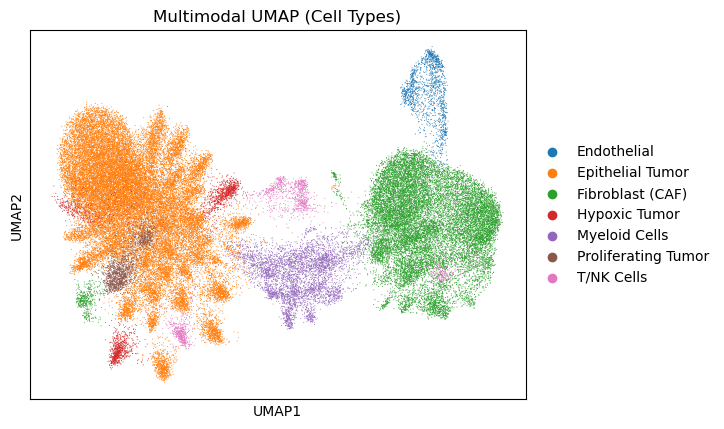

In [18]:
modalities = {
    "Gene": "X_gene",
    "CNN": "X_cnn",
    "Multimodal": "X_multi"
}

for name, rep in modalities.items():

    if rep not in adata.obsm:
        print(f"Skipping {name}")
        continue

    print(f"Running {name}")

    # IMPORTANT:
    # separate neighbors for each modality

    sc.pp.neighbors(
        adata,
        use_rep=rep,
        key_added=f"neighbors_{name}"
    )

    sc.tl.umap(
        adata,
        neighbors_key=f"neighbors_{name}"
    )

    sc.pl.umap(
        adata,
        color="cell_type",
        legend_loc="right margin",
        title=f"{name} UMAP (Cell Types)",
        show=False
    )

    plt.savefig(
        os.path.join(
            BASE_PATH,
            f"{name}_umap_celltypes.pdf"
        ),
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

### Manual Cluster Inspection

In [19]:
clusters = (
    adata.uns["rank_genes_groups"]["names"]
    .dtype.names
)

for cl in clusters:

    genes = (
        adata.uns["rank_genes_groups"]["names"][cl][:5]
    )

    print(f"\nCluster {cl}")

    print(
        "Top genes:",
        ", ".join(genes)
    )

    genes_str = " ".join(genes).lower()

    # =========================
    # Tumor / Epithelial
    # =========================

    if (
        "epcam" in genes_str or
        "cdh1" in genes_str or
        "muc1" in genes_str or
        "sox9" in genes_str or
        "lgr6" in genes_str
    ):

        if "mki67" in genes_str:
            print("→ Proliferating Tumor")

        else:
            print("→ Epithelial / Tumor")

    # =========================
    # Fibroblast / CAF
    # =========================

    elif (
        "col1a1" in genes_str or
        "fn1" in genes_str or
        "pdgfra" in genes_str or
        "col5a1" in genes_str
    ):

        print("→ Fibroblast / CAF")

    # =========================
    # Endothelial
    # =========================

    elif (
        "pecam1" in genes_str or
        "vwf" in genes_str or
        "flt4" in genes_str or
        "mmrn1" in genes_str
    ):

        print("→ Endothelial")

    # =========================
    # T / NK
    # =========================

    elif (
        "cd3e" in genes_str or
        "cd3d" in genes_str or
        "gzmb" in genes_str or
        "gzmh" in genes_str or
        "nkg7" in genes_str or
        "klrk1" in genes_str or
        "eomes" in genes_str or
        "itk" in genes_str or
        "tigit" in genes_str
    ):

        print("→ T / NK")

    # =========================
    # Myeloid
    # =========================

    elif (
        "cd14" in genes_str or
        "c1qc" in genes_str or
        "csf1r" in genes_str or
        "marco" in genes_str or
        "msr1" in genes_str or
        "cybb" in genes_str
    ):

        print("→ Myeloid")

    # =========================
    # B / Plasma
    # =========================

    elif (
        "cd79a" in genes_str or
        "mzb1" in genes_str
    ):

        print("→ B / Plasma Cells")

    # =========================
    # Antigen Presenting / DC
    # =========================

    elif (
        "cd207" in genes_str or
        "hla-dra" in genes_str
    ):

        print("→ Dendritic / APC")

    else:

        print("→ Mixed / Unknown")


Cluster 0
Top genes: FCER1A, MUC1, PKM, SERPINA1, LGR6
→ Epithelial / Tumor

Cluster 1
Top genes: KLRK1, SOX9, MUC1, SERPINA1, LGR6
→ Epithelial / Tumor

Cluster 2
Top genes: SERPINA1, LAMC2, MUC2, CDH1, CDKN1A
→ Epithelial / Tumor

Cluster 3
Top genes: TP63, LGR6, BST2, SOX9, MUC1
→ Epithelial / Tumor

Cluster 4
Top genes: CTSW, PKM, MUC1, SERPINA1, LGR6
→ Epithelial / Tumor

Cluster 5
Top genes: CD14, C1QC, CSF1R, CYBB, ITGB2
→ Myeloid

Cluster 6
Top genes: MSR1, PKM, MUC1, SERPINA1, SOX9
→ Epithelial / Tumor

Cluster 7
Top genes: SFRP2, FN1, COL1A1, COL5A1, PDGFRA
→ Fibroblast / CAF

Cluster 8
Top genes: KIT, COL1A1, LRP1, COL5A1, ENG
→ Fibroblast / CAF

Cluster 9
Top genes: JUN, SOD2, PTGS2, CXCL1, CEBPB
→ Mixed / Unknown

Cluster 10
Top genes: KLRB1, MUC1, SERPINA1, SOX9, SPRY2
→ Epithelial / Tumor

Cluster 11
Top genes: VEGFA, FN1, CXCR4, LAMC2, EGFR
→ Fibroblast / CAF

Cluster 12
Top genes: MUC1, PKM, LGR6, SOX9, BST2
→ Epithelial / Tumor

Cluster 13
Top genes: MMRN1, MUC1, PKM

In [20]:
# clusters = (
#     adata.uns["rank_genes_groups"]["names"]
#     .dtype.names
# )

# for cl in clusters:

#     genes = (
#         adata.uns["rank_genes_groups"]["names"][cl][:5]
#     )

#     print(f"\nCluster {cl}")

#     print(
#         "Top genes:",
#         ", ".join(genes)
#     )

#     genes_str = " ".join(genes).lower()

#     if "epcam" in genes_str or "cdh1" in genes_str:
#         print("→ Epithelial / Tumor")

#     elif "col1a1" in genes_str or "fn1" in genes_str:
#         print("→ Fibroblast")

#     elif "cd3e" in genes_str or "gzmb" in genes_str:
#         print("→ T / NK")

#     elif "cd14" in genes_str or "c1qc" in genes_str:
#         print("→ Myeloid")

#     elif "pecam1" in genes_str or "vwf" in genes_str:
#         print("→ Endothelial")

#     else:
#         print("→ Mixed / Unknown")

### Heatmap

In [21]:
clusters = (
    adata.uns["rank_genes_groups"]["names"]
    .dtype.names
)

top_genes = []

for cl in clusters:

    genes = (
        adata.uns["rank_genes_groups"]["names"][cl][:3]
    )

    top_genes.extend(genes)

# remove duplicates
top_genes = list(dict.fromkeys(top_genes))

print("Genes used:", len(top_genes))

Genes used: 63


In [22]:
# =========================
# Dendrogram
# =========================

sc.tl.dendrogram(
    adata,
    groupby="leiden"
)

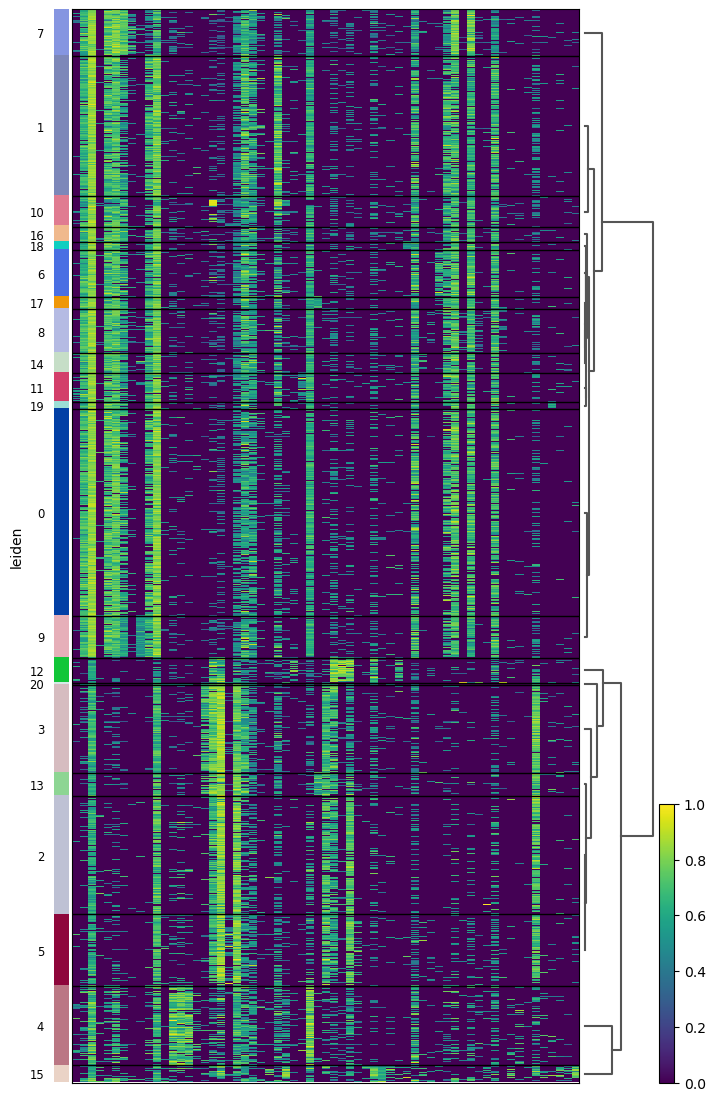

In [23]:
# =========================
# Heatmap Plot
# =========================

sc.pl.heatmap(
    adata,
    var_names=top_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="viridis",
    dendrogram=True,
    figsize=(8, 14)
)

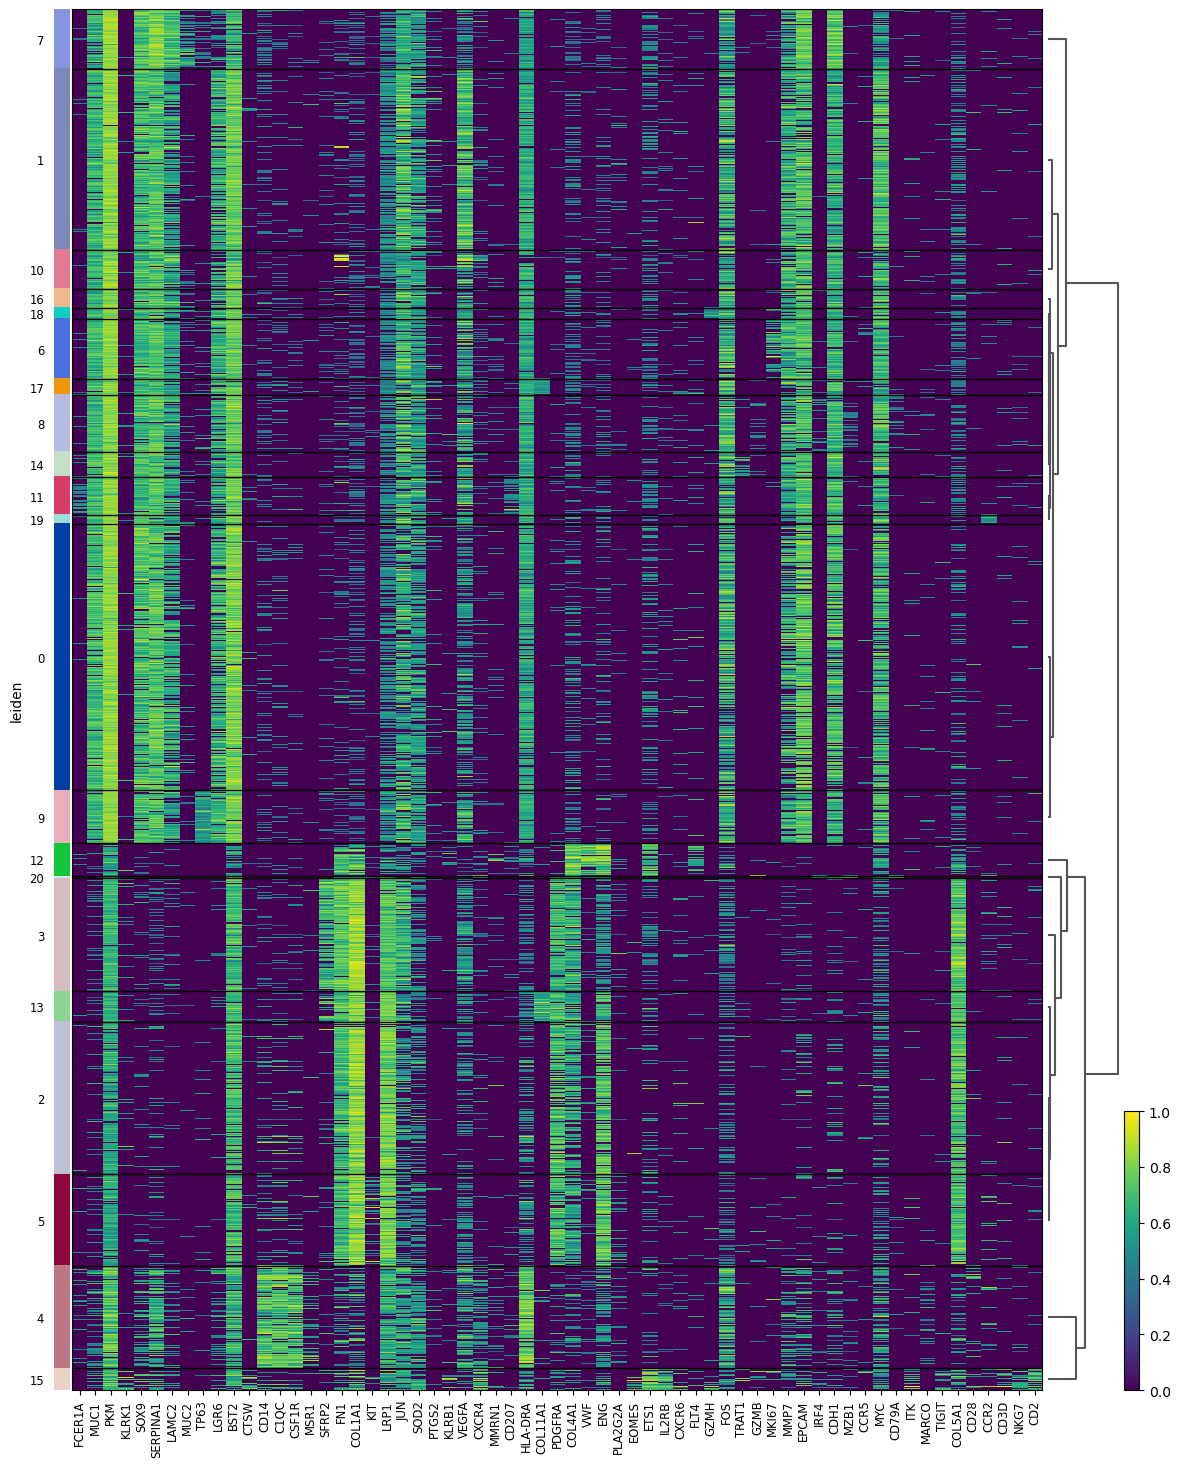

In [24]:
sc.pl.heatmap(
    adata,
    var_names=top_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="viridis",
    dendrogram=True,
    figsize=(14, 18),
    show_gene_labels=True
)

In [25]:
# =========================
# Gene-only clustering
# =========================

sc.pp.neighbors(
    adata,
    use_rep="X_gene",
    key_added="neighbors_gene"
)

sc.tl.umap(
    adata,
    neighbors_key="neighbors_gene"
)

sc.tl.leiden(
    adata,
    neighbors_key="neighbors_gene",
    key_added="leiden_Gene"
)

In [26]:
# =========================
# CNN-only clustering
# =========================

sc.pp.neighbors(
    adata,
    use_rep="X_cnn",
    key_added="neighbors_cnn"
)

sc.tl.umap(
    adata,
    neighbors_key="neighbors_cnn"
)

sc.tl.leiden(
    adata,
    neighbors_key="neighbors_cnn",
    key_added="leiden_CNN"
)

In [27]:
# =========================
# Multimodal clustering
# =========================

sc.pp.neighbors(
    adata,
    use_rep="X_multi",
    key_added="neighbors_multi"
)

sc.tl.umap(
    adata,
    neighbors_key="neighbors_multi"
)

sc.tl.leiden(
    adata,
    neighbors_key="neighbors_multi",
    key_added="leiden_Multimodal"
)

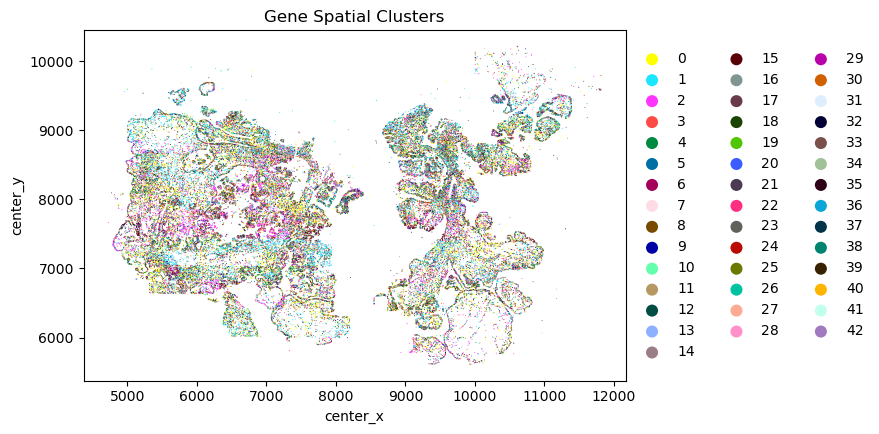

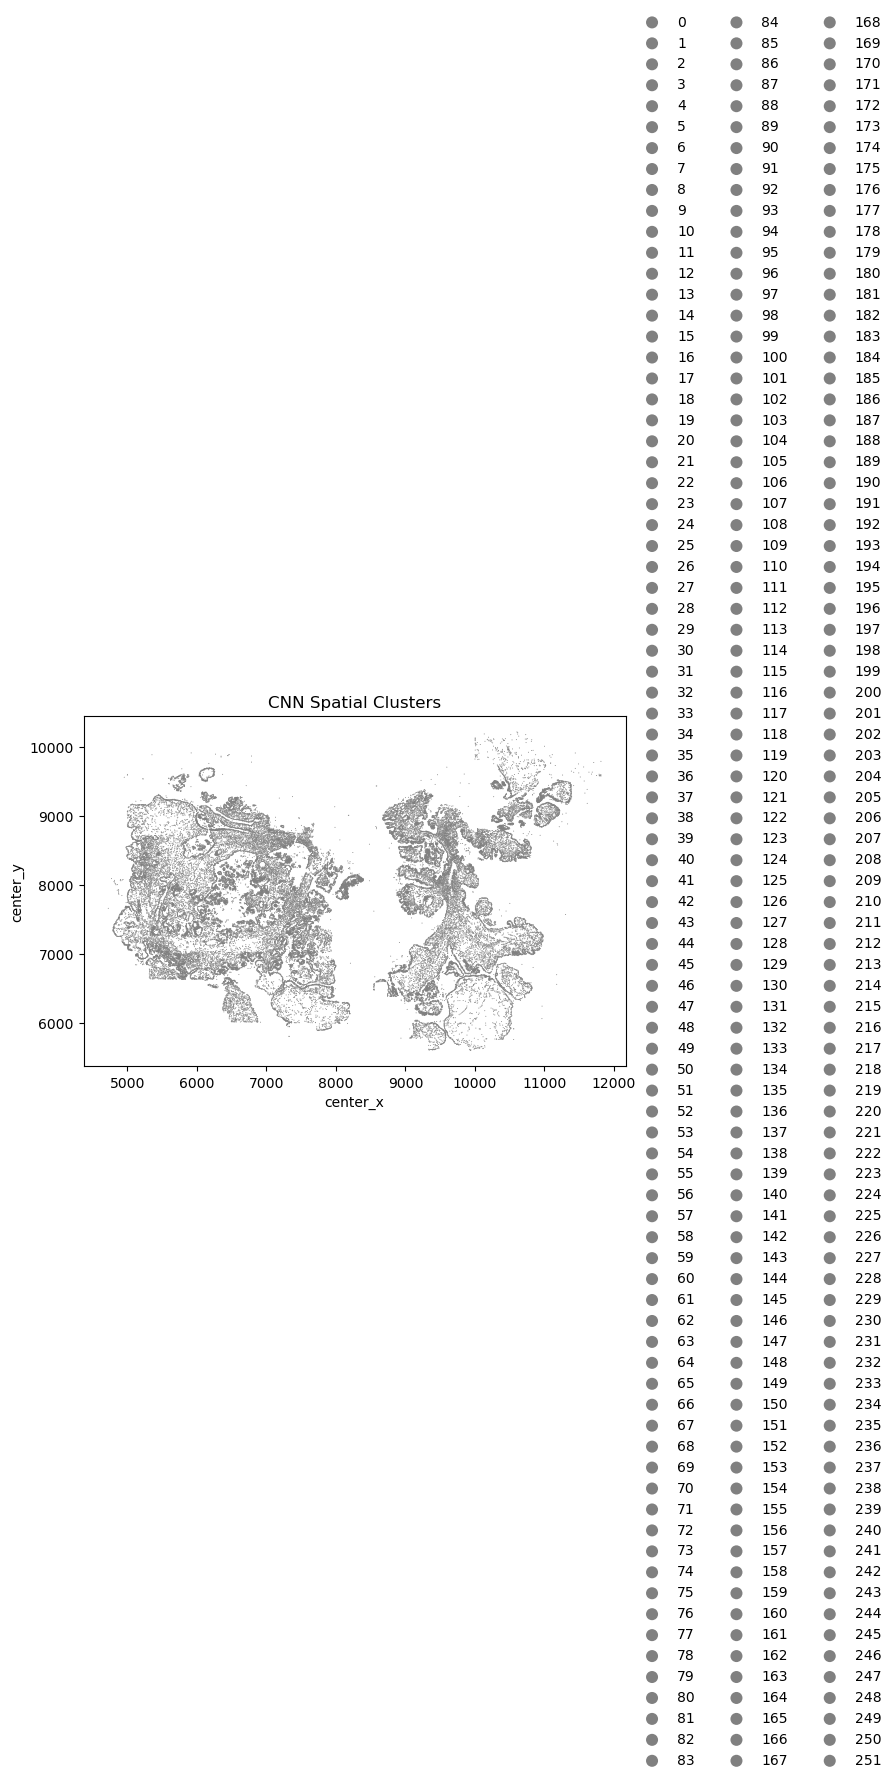

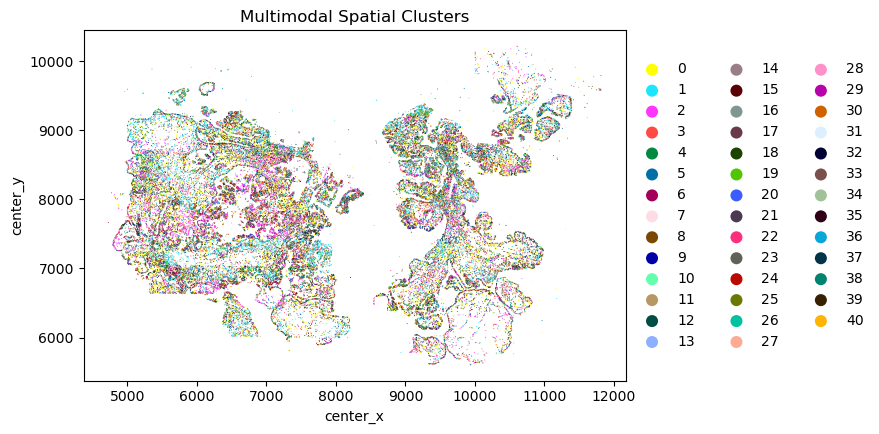

In [28]:
modalities = {
    "Gene": "leiden_Gene",
    "CNN": "leiden_CNN",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=cluster_col,
        title=f"{name} Spatial Clusters",
        show=True
    )

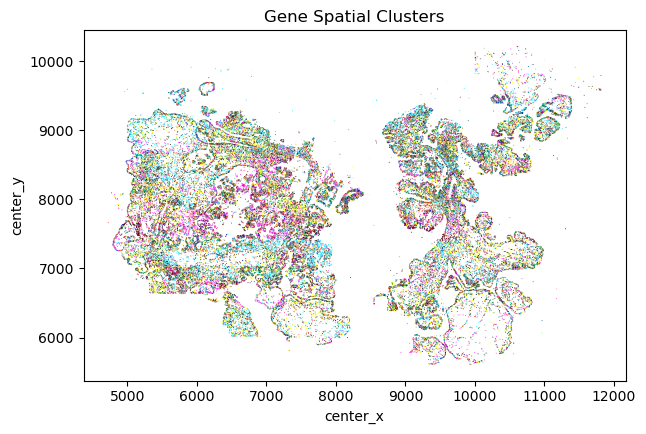

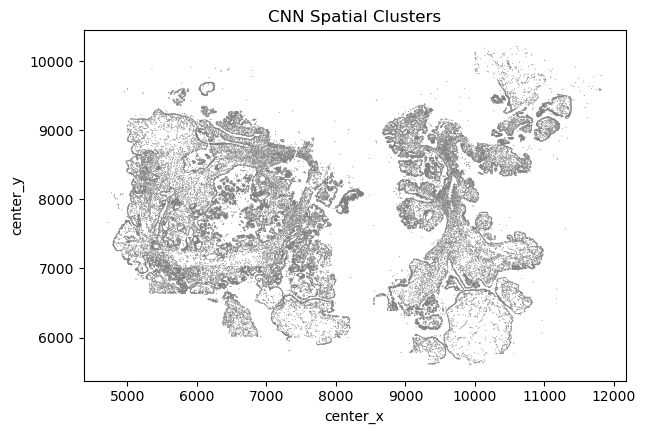

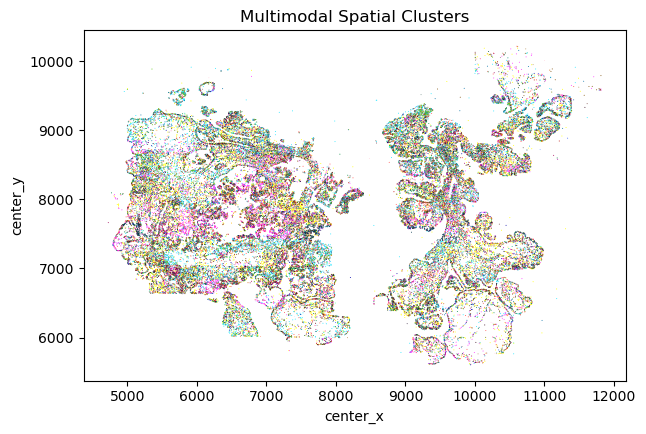

In [29]:
modalities = {
    "Gene": "leiden_Gene",
    "CNN": "leiden_CNN",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=cluster_col,
        title=f"{name} Spatial Clusters",
        legend_loc="none",
        show=True
    )

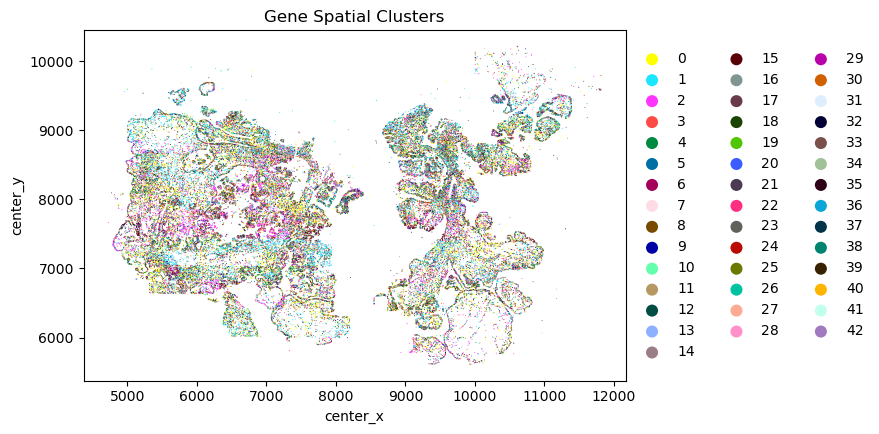

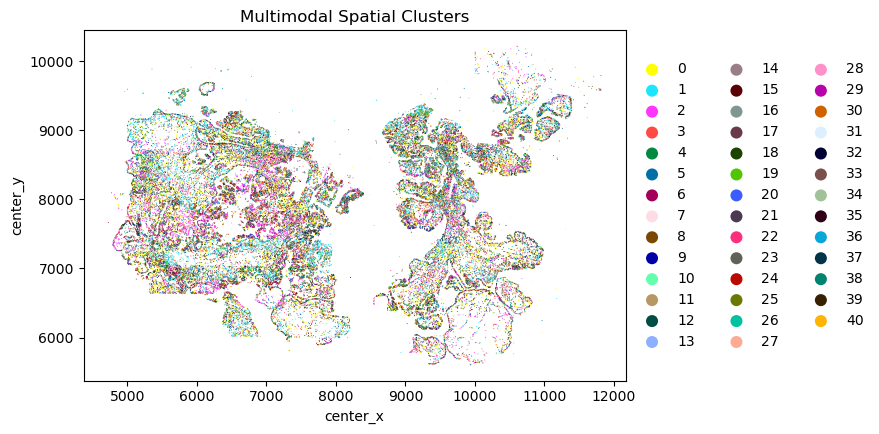

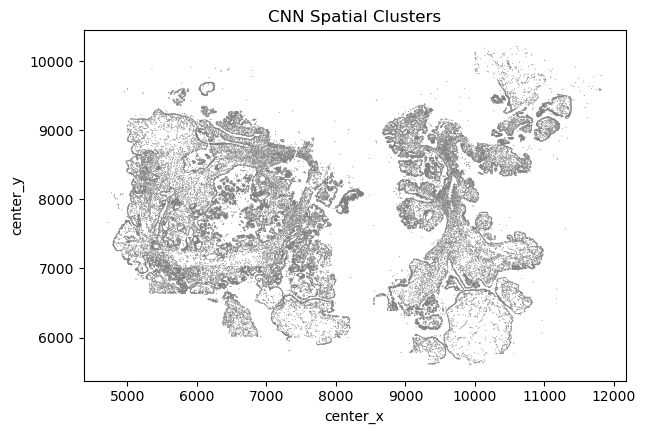

In [30]:
# Gene + Multimodal WITH labels

modalities = {
    "Gene": "leiden_Gene",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=cluster_col,
        title=f"{name} Spatial Clusters",
        legend_loc="right margin",
        show=True
    )


# CNN WITHOUT labels

sc.pl.scatter(
    adata,
    x="center_x",
    y="center_y",
    color="leiden_CNN",
    title="CNN Spatial Clusters",
    legend_loc="none",
    show=True
)

Running Gene


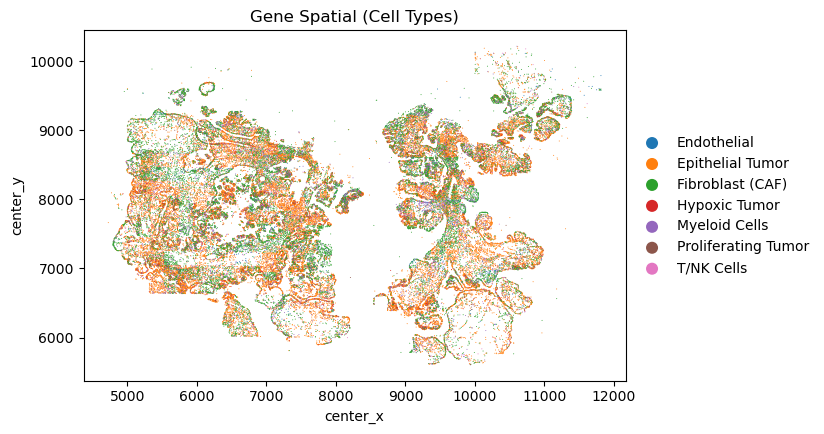

Running CNN


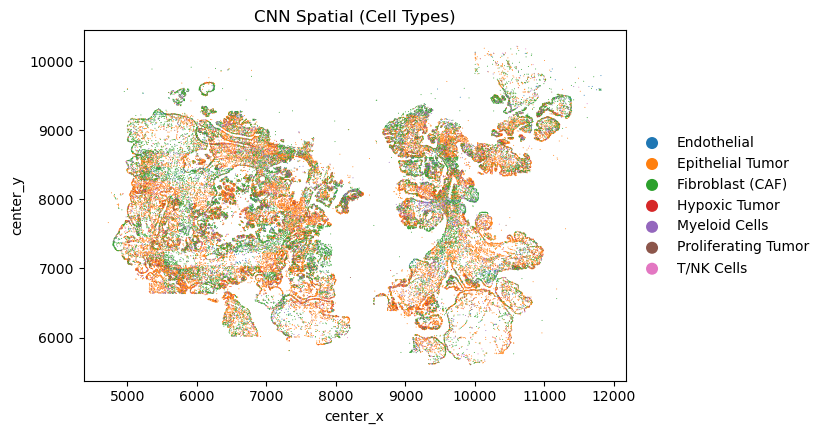

Running Multimodal


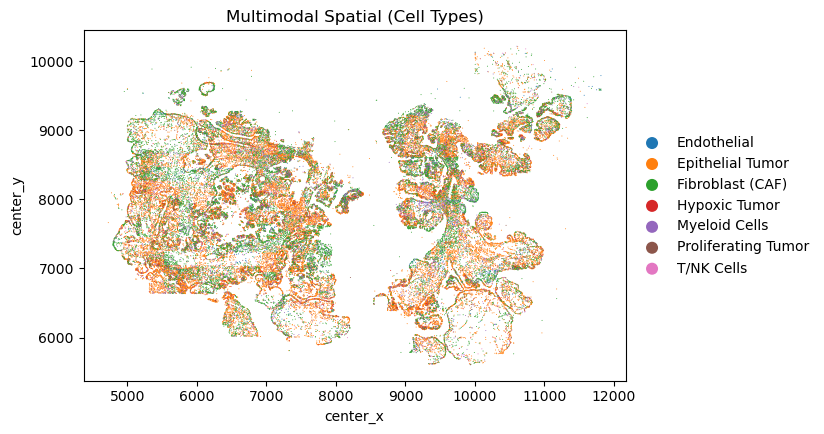

In [31]:
# =========================
# Modality-Specific Spatial Cell Type Plots
# =========================

modalities = {
    "Gene": "X_gene",
    "CNN": "X_cnn",
    "Multimodal": "X_multi"
}

for name, rep in modalities.items():

    if rep not in adata.obsm:
        print(f"Skipping {name}")
        continue

    print(f"Running {name}")

    # Compute neighbours for the modality (optional if already computed)
    sc.pp.neighbors(
        adata,
        use_rep=rep,
        key_added=f"neighbors_{name}"
    )

    # Spatial plot using the original cell type annotations
    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color="cell_type",
        legend_loc="right margin",
        title=f"{name} Spatial (Cell Types)",
        show=False
    )

    plt.savefig(
        os.path.join(
            BASE_PATH,
            f"{name}_spatial_celltypes.pdf"
        ),
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

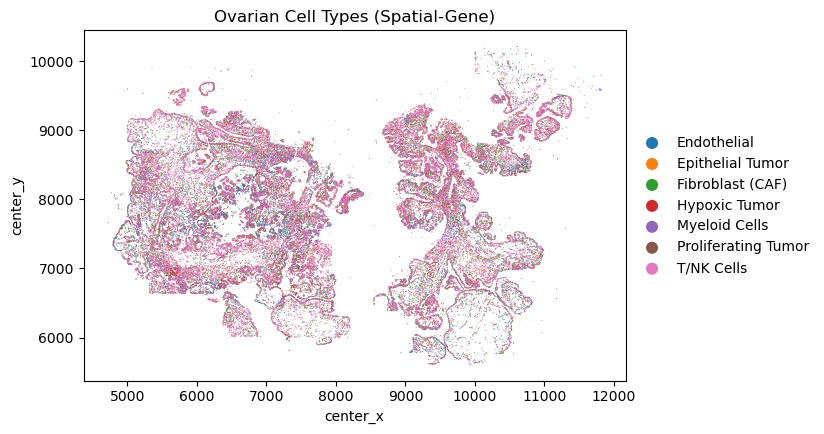

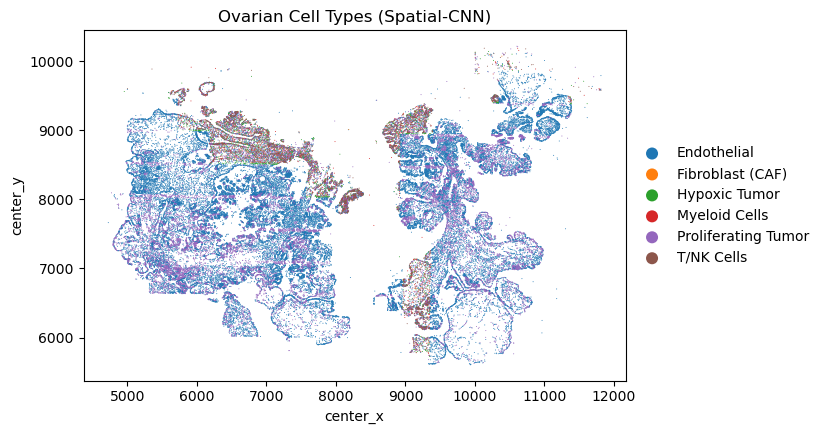

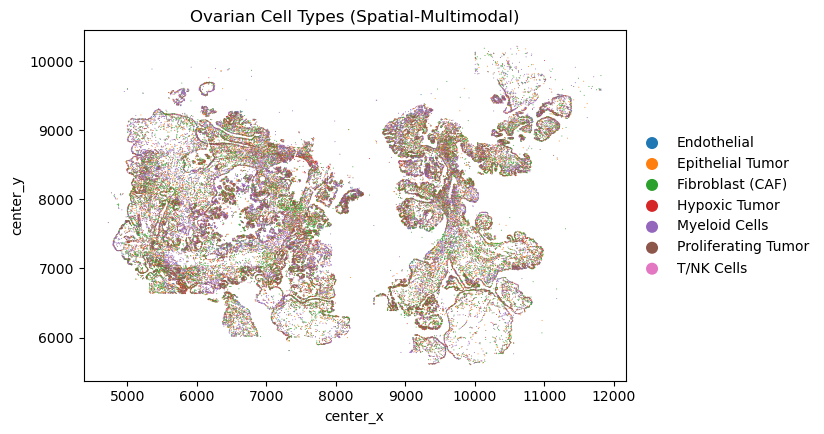

In [32]:
# =========================
# Modality-Specific Spatial Cell Types
# =========================

modalities = {
    "Gene": "leiden_Gene",
    "CNN": "leiden_CNN",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    # map modality clusters to existing cell type labels
    cluster_to_celltype = (
        adata.obs[[cluster_col, "cell_type"]]
        .drop_duplicates()
        .set_index(cluster_col)["cell_type"]
        .to_dict()
    )

    adata.obs[f"{cluster_col}_celltype"] = (
        adata.obs[cluster_col]
        .map(cluster_to_celltype)
        .astype("category")
    )

    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=f"{cluster_col}_celltype",
        legend_loc="right margin",
        title=f"Ovarian Cell Types (Spatial-{name})",
        show=False
    )

    plt.savefig(
        os.path.join(
            BASE_PATH,
            f"{name}_spatial_celltypes.pdf"
        ),
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

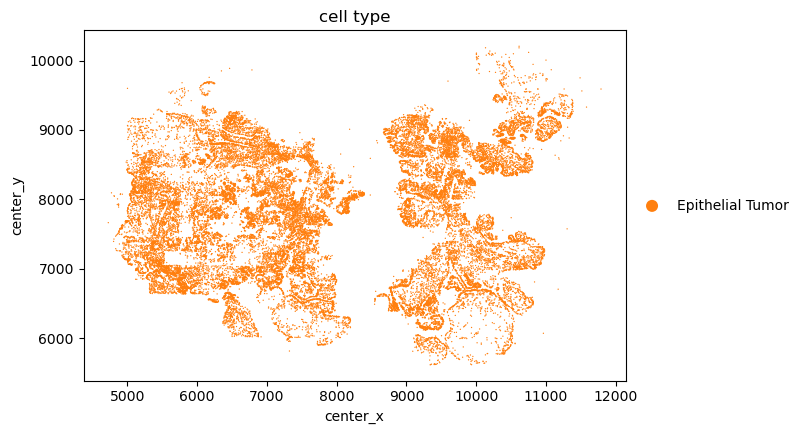

In [33]:
epi = adata[adata.obs["cell_type"] == "Epithelial Tumor"]

sc.pl.scatter(
    epi,
    x="center_x",
    y="center_y",
    color="cell_type",
)

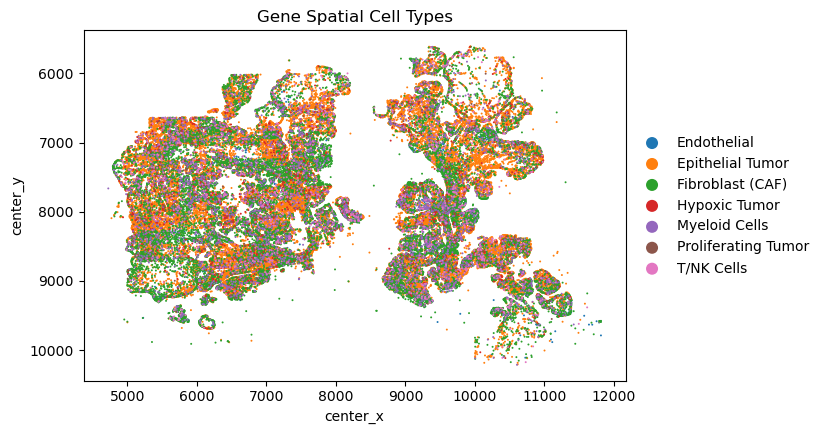

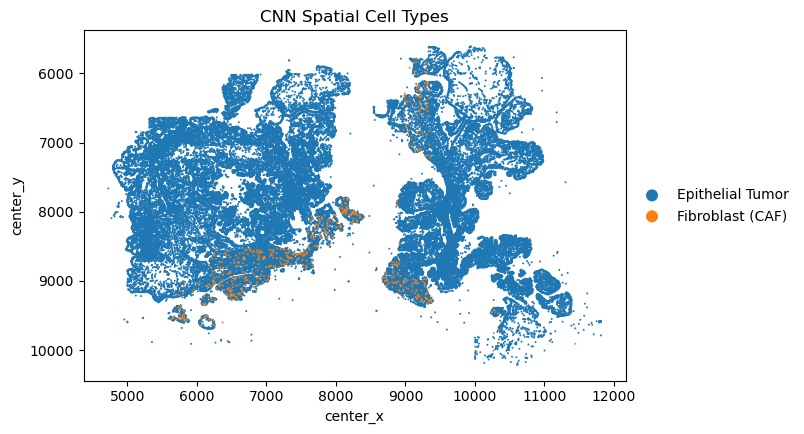

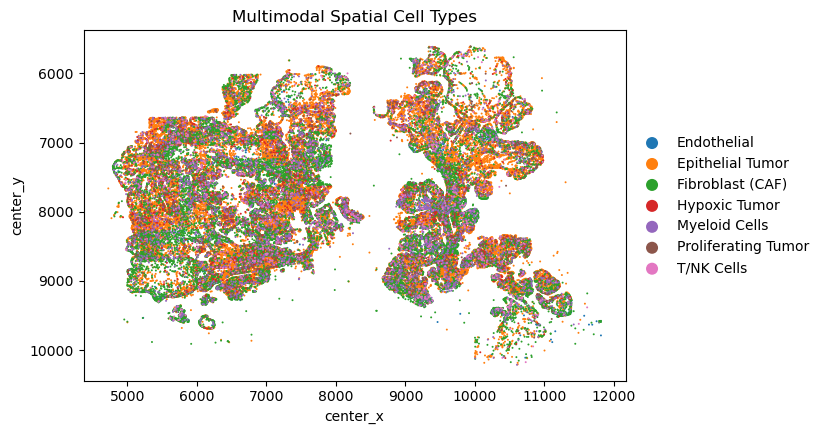

In [36]:
# ==========================================
# Modality-Specific Spatial Cell Types
# (Majority-vote mapping)
# ==========================================

modalities = {
    "Gene": "leiden_Gene",
    "CNN": "leiden_CNN",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    # Assign each modality cluster to its majority cell type
    cluster_to_celltype = (
        adata.obs
        .groupby(cluster_col)["cell_type"]
        .agg(lambda x: x.value_counts().idxmax())
        .to_dict()
    )

    # Create modality-specific cell type labels
    adata.obs[f"{cluster_col}_celltype"] = (
        adata.obs[cluster_col]
        .map(cluster_to_celltype)
        .astype("category")
    )

    # Plot
    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=f"{cluster_col}_celltype",
        legend_loc="right margin",
        title=f"{name} Spatial Cell Types",
        size=8,
        frameon=False,
        show=False
    )

    plt.gca().invert_yaxis()

    plt.savefig(
        os.path.join(
            BASE_PATH,
            f"{name}_spatial_celltypes.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()